https://stable-baselines3.readthedocs.io/en/master/modules/ppo.html

## PPO 모델 이용하여 학습

In [ ]:
!pip install tensorboard

In [1]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import SubprocVecEnv


if __name__=="__main__":
    env = make_vec_env("CartPole-v1", n_envs=8, vec_env_cls=SubprocVecEnv)
    model = PPO(
        "MlpPolicy", 
        env, 
        verbose=1,  #로그 출력 옵션(0:없음,1:기본 요약, 2:세부정보)
        tensorboard_log="./ppo_cartpole_log/",   # 로그 경로 지정
        device = 'cpu'
    )
    model.learn(total_timesteps=500_000)  # 충분히 길게 학습

Using cpu device
Logging to ./ppo_cartpole_log/PPO_3
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 20.5     |
|    ep_rew_mean     | 20.5     |
| time/              |          |
|    fps             | 13955    |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 16384    |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 36.9        |
|    ep_rew_mean          | 36.9        |
| time/                   |             |
|    fps                  | 5460        |
|    iterations           | 2           |
|    time_elapsed         | 6           |
|    total_timesteps      | 32768       |
| train/                  |             |
|    approx_kl            | 0.015845664 |
|    clip_fraction        | 0.264       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.68       |
|    explained_vari

1. cartpole-v1 예제 환경 8개를 만들고, 각 환경을 서브프로세스에서 병렬 실행하는 벡터라이즈드 환경으로 묶어줌

2. PPO 알고리즘 객체를 생성하고 정책/가치망은 MLP로, 학습 및 추론은 CPU로 (cartpole은 CPU로도 충분한 단순 예제)

3. 환경과 총 25,000 step 상호작용하며 학습 진행. 루프마다 병렬 환경에서 롤아웃 수집, 어드밴티지 계산, 클립드 목적함수로 정책 업데이트, 가치함수 MSE 최소화 , 엔트로피 보너스 적용 , 이후 다음 롤아웃을 반복

Loaded log file: ./ppo_cartpole_log/PPO_3/events.out.tfevents.1761485672.DESKTOP-O9ASPE5.21344.0
['rollout/ep_len_mean', 'rollout/ep_rew_mean', 'time/fps', 'train/approx_kl', 'train/clip_fraction', 'train/clip_range', 'train/entropy_loss', 'train/explained_variance', 'train/learning_rate', 'train/loss', 'train/policy_gradient_loss', 'train/value_loss']


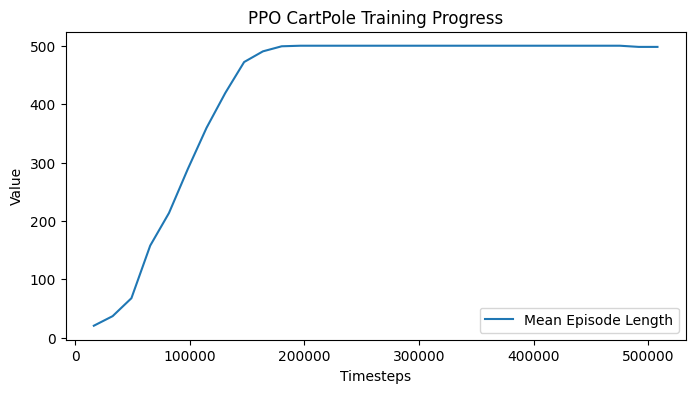

In [8]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt
import os

# 로그 디렉토리 지정
log_dir = "./ppo_cartpole_log/PPO_3/"  # 여기에 tfevents 파일이 있음
files = [f for f in os.listdir(log_dir) if "events.out.tfevents" in f]
event_path = os.path.join(log_dir, files[0])
print(f"Loaded log file: {event_path}")

# 이벤트 로더 초기화
ea = event_accumulator.EventAccumulator(event_path)
ea.Reload()  # 데이터 불러오기

# 사용 가능한 태그 확인 (e.g., rollout/ep_rew_mean 등)
print(ea.Tags()["scalars"])

# 원하는 지표 가져오기
rew_data = ea.Scalars("rollout/ep_rew_mean")
len_data = ea.Scalars("rollout/ep_len_mean")

# (step, value) 추출
steps = [x.step for x in rew_data]
# rewards = [x.value for x in rew_data]
lengths = [x.value for x in len_data]

# 그래프 출력
plt.figure(figsize=(8, 4))
# plt.plot(steps, rewards, label="Mean Reward")
plt.plot(steps, lengths, label="Mean Episode Length")
plt.xlabel("Timesteps")
plt.ylabel("Value")
plt.title("PPO CartPole Training Progress")
plt.legend()
plt.show()



### log 기록들

rollout/

ep_len_mean : 한 에피소드 평균 스텝 수

ep_rew_mean : 한 에피소드 평균 보상

--------------------------------------
time/

fps : 초당 처리된 스텝 수

--------------------------------------
train/

approx_kl : 새 정책과 이전 정책의 평균 KL 발산 (근사치)

clip_fraction : r_t 비율이 클리핑된 샘플 비율

clip_range : 클리핑 허용 범위(하이퍼 파라미터)

entropy_loss : 정책의 엔트로피(탐색도)

experienced_variance : 가치함수 예측력

learning_rate : 학습률

loss : 총 손실(청책+가치+엔트로피)

policy_gradient_loss : 정책 손실(PPO의 클립된 surrogate objective의 실제 gradient 손실값)

value_loss : 가치함수 MSE 손실


## 학습된 모델로 테스트 시각화

In [ ]:
import gymnasium as gym 
import time 
from stable_baselines3 import PPO

n_episodes = 2
test_env = gym.make("CartPole-v1", render_mode = 'human')
for ep in range(n_episodes):
    obs, _ = test_env.reset()
    done = False
    steps = 0
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = test_env.step(action)
        test_env.render()
        steps += 1
        time.sleep(0.02)
        if done or truncated:
            print(f"Episode {ep+1} finished after {steps} steps.")
            break

test_env.close()

소스 코드 링크:

https://stable-baselines3.readthedocs.io/en/master/_modules/stable_baselines3/ppo/ppo.html